# Prediction Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  
  
from scripts.data_operation import transform_to_daily_stays
from scripts.constants import START_DATE, END_DATE, PREDICTION_HORIZON_DAYS

from scripts.final.data_preparation import (
    compute_base_prices,
    compute_relative_price_index,
    compute_occupancy_rate,
    build_historical_sample,
    prepare_full_occupancy_series,
)
from scripts.final.demand_forecasting import fit_sarima_model, forecast_occupancy
from scripts.final.distribution_estimation import estimate_joint_density, extract_conditional_distribution
from scripts.final.pricing import select_price_quantile, recommend_apartment_prices

## Section 2.2 — Data Aggregation and Preprocessing

In [3]:
relevant_data = pd.read_csv('data/relevant_data.csv', parse_dates=['start_date', 'end_date'])

listing_summary = relevant_data.groupby('apartment_id').agg(
    max_people_count=('beds_count', 'max'),
    num_reservations=('apartment_id', 'count'),
).reset_index()
# listing_summary = pd.read_csv('data/listing_summary.csv')

total_capacity = listing_summary['max_people_count'].sum()

print(f"Apartments in segment : {len(listing_summary)}")
print(f"Total capacity (beds) : {total_capacity}")
listing_summary.head()

Apartments in segment : 13
Total capacity (beds) : 57


,apartment_id,max_people_count,num_reservations
0,0,3,142
1,1,4,128
2,2,8,127
3,3,5,99
4,4,4,119


In [4]:
# Expand booking records to one row per apartment per night
daily_stays = transform_to_daily_stays(relevant_data)
daily_stays['stay_date'] = pd.to_datetime(daily_stays['stay_date'])
daily_stays = daily_stays[
    (daily_stays['stay_date'] >= START_DATE) &
    (daily_stays['stay_date'] < END_DATE)
].reset_index(drop=True)

print(f"Records : {len(daily_stays)}")
print(f"Period  : {daily_stays['stay_date'].min().date()} -> {daily_stays['stay_date'].max().date()}")
daily_stays.head()


# Aggregated daily view
daily_agg_ilust = (
    daily_stays
    .groupby('stay_date')
    .agg(
        beds_sold=('beds_count', 'sum'),
        apartments_occupied=('apartment_id', 'nunique'),
        avg_bed_price=('nightly_bed_rate', 'mean'),
    )
    .assign(occupancy_rate=lambda df: (df['beds_sold'] / total_capacity).round(4))
    .reset_index()
)

print(f"Days with at least one booking: {len(daily_agg_ilust)}")
daily_agg_ilust.head(10)

Records : 1931
Period  : 2024-10-27 -> 2025-05-26
Days with at least one booking: 212


,stay_date,beds_sold,apartments_occupied,avg_bed_price,occupancy_rate
0,2024-10-27,31,11,140288.090909,0.5439
1,2024-10-28,32,12,150943.083333,0.5614
2,2024-10-29,25,9,147942.222222,0.4386
3,2024-10-30,14,6,139036.166667,0.2456
4,2024-10-31,32,11,160179.000000,0.5614
5,2024-11-01,36,12,166870.250000,0.6316
6,2024-11-02,36,12,166870.250000,0.6316
7,2024-11-03,9,3,166042.333333,0.1579
8,2024-11-04,8,3,137484.000000,0.1404
9,2024-11-05,11,5,104167.600000,0.1930


In [5]:
# Base price p_bar_a: historical average price per bed for each apartment
base_prices = compute_base_prices(daily_stays)

print("Base prices per bed (p_bar_a):")
base_prices.reset_index().rename(columns={'nightly_bed_rate': 'base_price_per_bed'})

Base prices per bed (p_bar_a):


,apartment_id,base_price_per_bed
0,0,188090.454545
1,1,188296.149171
2,2,146599.735849
3,3,132129.679389
4,4,134438.878453
5,5,150937.328947
6,6,162413.148387
7,7,162769.662420
8,8,215648.933333
9,9,161941.715116


In [6]:
# Relative price index r_t: beds-weighted average of (p_{a,t} / p_bar_a) across all apartments
relative_price_index = compute_relative_price_index(daily_stays, base_prices)

print(f"Days with r_t defined : {len(relative_price_index)}")
print(f"r_t range             : {relative_price_index.min():.3f} - {relative_price_index.max():.3f}")
print(f"r_t mean              : {relative_price_index.mean():.3f}  (should be approx 1.0)")

Days with r_t defined : 212
r_t range             : 0.466 - 1.991
r_t mean              : 0.906  (should be approx 1.0)


In [7]:
# Aggregated daily view for illustration — one row per day
daily_agg_ilust = (
    daily_stays
    .groupby('stay_date')
    .agg(
        beds_sold=('beds_count', 'sum'),
        apartments_occupied=('apartment_id', 'nunique'),
        avg_bed_price=('nightly_bed_rate', 'mean'),
    )
    .assign(occupancy_rate=lambda df: (df['beds_sold'] / total_capacity).round(4))
    .reset_index()
    .merge(relative_price_index.rename('relative_price_index').reset_index(), on='stay_date', how='left')
)

print(f"Days with at least one booking: {len(daily_agg_ilust)}")
daily_agg_ilust.head(10)

Days with at least one booking: 212


,stay_date,beds_sold,apartments_occupied,avg_bed_price,occupancy_rate,relative_price_index
0,2024-10-27,31,11,140288.090909,0.5439,0.815007
1,2024-10-28,32,12,150943.083333,0.5614,0.833195
2,2024-10-29,25,9,147942.222222,0.4386,0.797069
3,2024-10-30,14,6,139036.166667,0.2456,0.850429
4,2024-10-31,32,11,160179.000000,0.5614,0.961403
5,2024-11-01,36,12,166870.250000,0.6316,1.001677
6,2024-11-02,36,12,166870.250000,0.6316,1.001677
7,2024-11-03,9,3,166042.333333,0.1579,0.968866
8,2024-11-04,8,3,137484.000000,0.1404,0.888517
9,2024-11-05,11,5,104167.600000,0.1930,0.577214


Historical sample size : 212 days
Occupancy range        : 0.053 - 0.684
Relative price range   : 0.466 - 1.991


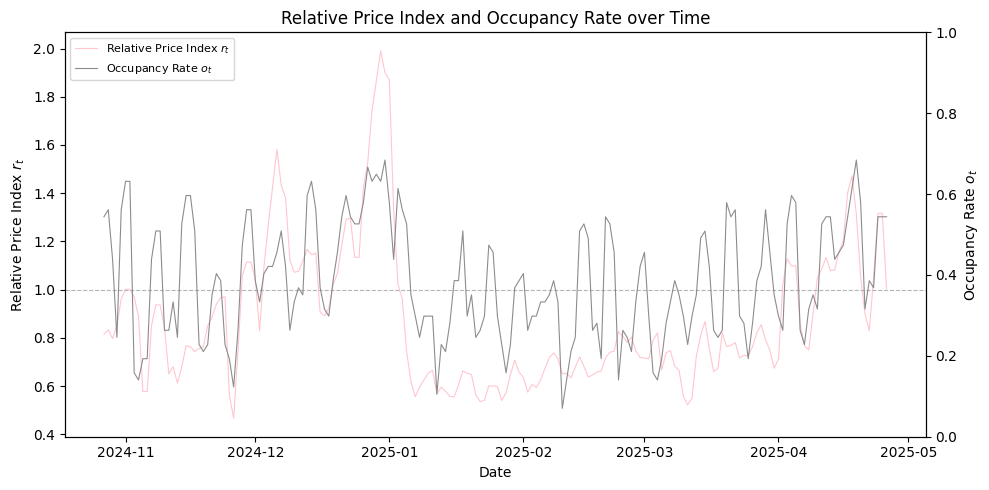

In [11]:
# Occupancy rate o_t on days with at least one booking
occupancy_rate_booked = compute_occupancy_rate(daily_stays, total_capacity)

# Historical sample D = {(o_t, r_t)}
historical_sample = build_historical_sample(occupancy_rate_booked, relative_price_index)

print(f"Historical sample size : {len(historical_sample)} days")
print(f"Occupancy range        : {historical_sample['occupancy_rate'].min():.3f} - {historical_sample['occupancy_rate'].max():.3f}")
print(f"Relative price range   : {historical_sample['relative_price_index'].min():.3f} - {historical_sample['relative_price_index'].max():.3f}")

fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# Primary axis: relative price index (pink)
ln1 = axes.plot(relative_price_index.index[:-30], relative_price_index.values[:-30],
                color='pink', linewidth=0.8, alpha=0.9, label='Relative Price Index $r_t$')
axes.axhline(1.0, color='#B4B4B4', linestyle='--', linewidth=0.8)
axes.set_title('Relative Price Index and Occupancy Rate over Time')
axes.set_xlabel('Date')
axes.set_ylabel('Relative Price Index $r_t$')
axes.tick_params(axis='y')

# Secondary axis: occupancy rate (gray)
ax0b = axes.twinx()
ln2 = ax0b.plot(occupancy_rate_booked.index[:-30], occupancy_rate_booked.values[:-30],
                color='gray', linewidth=0.8, alpha=0.9, label='Occupancy Rate $o_t$')
ax0b.set_ylabel('Occupancy Rate $o_t$')
ax0b.set_ylim(0, 1)
ax0b.tick_params(axis='y')

lines = ln1 + ln2
axes.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


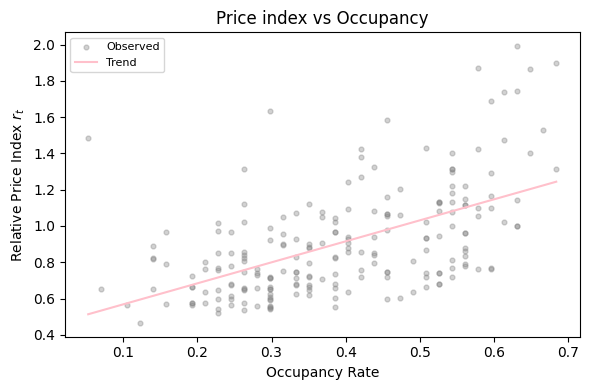

Slope of trend line: 1.157 (indicates how much r_t changes on average with a 1 percentage point change in o_t)
Correlation between occupancy rate and relative price index: 0.554 (indicates strength of linear relationship)


In [13]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    historical_sample['occupancy_rate'],
    historical_sample['relative_price_index'],
    color='grey', alpha=0.35, s=12, label='Observed'
)

# Pink trend line
x = historical_sample['occupancy_rate'].values
y = historical_sample['relative_price_index'].values
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, m * x_line + b, color='pink', linewidth=1.5, label=f'Trend')

ax.set_title('Price index vs Occupancy')
ax.set_xlabel('Occupancy Rate')
ax.set_ylabel('Relative Price Index $r_t$')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# print slope of trend line
print(f"Slope of trend line: {m:.3f} (indicates how much r_t changes on average with a 1 percentage point change in o_t)")

# corelation between o_t and r_t
correlation = historical_sample['occupancy_rate'].corr(historical_sample['relative_price_index'])
print(f"Correlation between occupancy rate and relative price index: {correlation:.3f} (indicates strength of linear relationship)")


## Section 2.3 — Demand Forecasting with SARIMA

Training : 2024-10-27 -> 2025-04-26  (182 days)
Test     : 2025-04-27  -> 2025-05-26   (30 days)


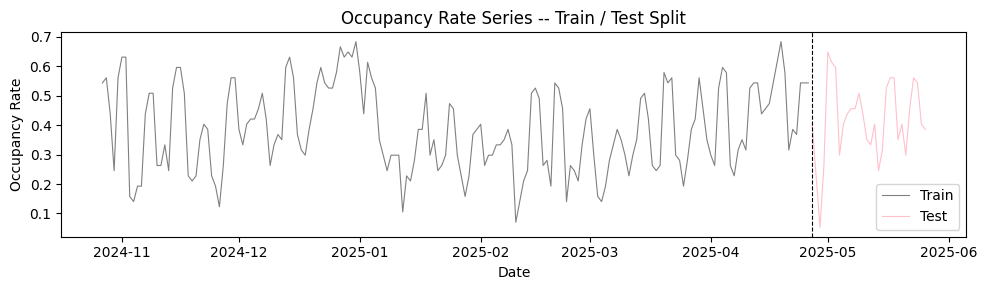

In [16]:
# Full occupancy series including zeros on unbooked days -- required for SARIMA
full_occupancy_series = prepare_full_occupancy_series(daily_stays, total_capacity, START_DATE, END_DATE)

train_occupancy = full_occupancy_series[:-PREDICTION_HORIZON_DAYS]
test_occupancy  = full_occupancy_series[-PREDICTION_HORIZON_DAYS:]

print(f"Training : {train_occupancy.index[0].date()} -> {train_occupancy.index[-1].date()}  ({len(train_occupancy)} days)")
print(f"Test     : {test_occupancy.index[0].date()}  -> {test_occupancy.index[-1].date()}   ({len(test_occupancy)} days)")

plt.figure(figsize=(10, 3))
plt.plot(train_occupancy.index, train_occupancy.values, label='Train', linewidth=0.8, color='gray')
plt.plot(test_occupancy.index,  test_occupancy.values,  label='Test',  linewidth=0.8, color='pink')
plt.axvline(test_occupancy.index[0], color='black', linestyle='--', linewidth=0.8)
plt.title('Occupancy Rate Series -- Train / Test Split')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Fit SARIMA with weekly seasonality (m=7)
sarima_model = fit_sarima_model(train_occupancy, seasonal_period=7)
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=-341.805, Time=0.45 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=-185.765, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=-319.324, Time=0.16 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=-282.194, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=197.251, Time=0.00 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=-324.121, Time=0.27 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=-324.198, Time=0.42 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=-339.770, Time=0.63 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=-345.305, Time=0.74 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=-324.179, Time=0.53 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=inf, Time=0.91 sec
 ARIMA(1,0,2)(1,0,2)[7] intercept   : AIC=-345.223, Time=0.66 sec
 ARIMA(2,0,1)(1,0,2)[7] intercept   : AIC=-344.605, Time=0.55 sec
 ARIMA(3,0,2)(1,0,2)[7] intercept   : AIC=-329.290, Time=0.90 sec
 ARIMA(2,0,3)(1,0,2)[7] intercept   : A

MAE  : 0.0784
RMSE : 0.0977


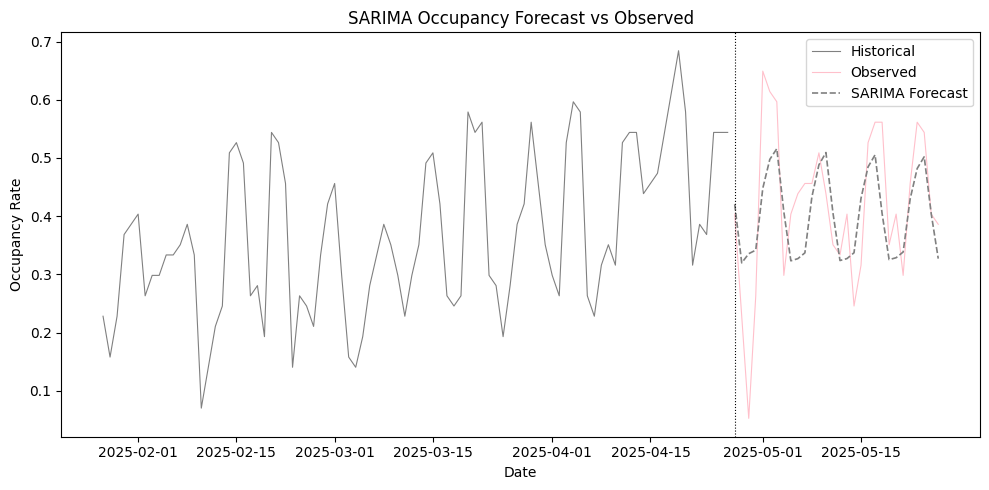

In [150]:
forecasted_occupancy = forecast_occupancy(sarima_model, horizon=PREDICTION_HORIZON_DAYS)
forecasted_dates = test_occupancy.index

mae  = np.mean(np.abs(test_occupancy.values - forecasted_occupancy))
rmse = np.sqrt(np.mean((test_occupancy.values - forecasted_occupancy) ** 2))
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(train_occupancy.index[-90:], train_occupancy.values[-90:], label='Historical', linewidth=0.8, color='gray')
plt.plot(forecasted_dates, test_occupancy.values,   label='Observed',          linewidth=0.8,   color='pink' )
plt.plot(forecasted_dates, forecasted_occupancy,    label='SARIMA Forecast', linewidth=1.2,linestyle='--', color='gray')
plt.axvline(forecasted_dates[0], color='black', linestyle=':', linewidth=0.8)
plt.title('SARIMA Occupancy Forecast vs Observed')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate')
plt.legend()
plt.tight_layout()
plt.show()

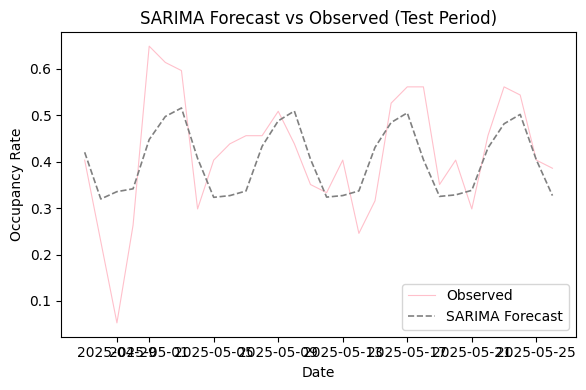

In [154]:
plt.figure(figsize=(6, 4))
plt.plot(forecasted_dates, test_occupancy.values, label='Observed', linewidth=0.8, color='pink')
plt.plot(forecasted_dates, forecasted_occupancy,  label='SARIMA Forecast', linewidth=1.2, linestyle='--', color='gray')
plt.title('SARIMA Forecast vs Observed (Test Period)')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Section 2.4 — Estimation of Historical Occupancy-Price Distribution

In [21]:
kde, occupancy_grid, price_grid, density_grid = estimate_joint_density(historical_sample, grid_size=100)

print(f"KDE fitted on {len(historical_sample)} observations")
print(f"Grid: {len(occupancy_grid)} occupancy x {len(price_grid)} price points")

KDE fitted on 212 observations
Grid: 100 occupancy x 100 price points


In [1]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cf = axes[0].contourf(occupancy_grid, price_grid, density_grid, levels=20, cmap='Greys')
fig.colorbar(cf, ax=axes[0], label='Density')
axes[0].set_title('Estimated Joint Density $\hat{f}(o, r)$')
axes[0].set_xlabel('Occupancy Rate o')
axes[0].set_ylabel('Relative Price Index r')

scatter = axes[1].scatter(
    historical_sample['occupancy_rate'],
    historical_sample['relative_price_index'],
    alpha=0.4,
    s=10,
    color='gray',
    label='Observed'
)

# Contour plot (no label here)
cs = axes[1].contour(
    occupancy_grid,
    price_grid,
    density_grid,
    levels=8,
    colors='pink',
    linewidths=0.8,
    alpha=0.6
)

# Titles and labels
axes[1].set_title('Joint Density Overlaid on Data')
axes[1].set_xlabel('Occupancy Rate o')
axes[1].set_ylabel('Relative Price Index r')

# Create proxy artist for contour
contour_proxy = Line2D([0], [0], color='pink', lw=1)

# Get existing legend handles and labels, then append contour
handles, labels = axes[1].get_legend_handles_labels()
handles.append(contour_proxy)
labels.append('Density Contours')

# Final legend
axes[1].legend(handles, labels)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [42]:
#  Illustration: Compute std of conditional distribution f_hat(r | o=0.5)

occupancy_value = 0.4
prices_axis, conditional_density = extract_conditional_distribution(
    occupancy_grid, price_grid, density_grid, occupancy_value
)
# compute standart deviation of conditional distribution
conditional_mean = np.sum(prices_axis * conditional_density) / np.sum(conditional_density)
conditional_variance = np.sum(((prices_axis - conditional_mean) ** 2) * conditional_density) / np.sum(conditional_density)
conditional_std = np.sqrt(conditional_variance)
print(f"Conditional mean of r given o={occupancy_value}: {conditional_mean:.3f}")
print(f"Conditional std of r given o={occupancy_value}: {conditional_std:.3f}")

# print min and max r values of the observed data:
print(f"Observed r range: {historical_sample['relative_price_index'].min():.3f} - {historical_sample['relative_price_index'].max():.3f}")

# print std as percentage of mean:
print(f"Conditional std as % of mean: {(conditional_std / conditional_mean) *100:.1f}% (indicates relative uncertainty in price index at occupancy {occupancy_value})")
# print std as percentage of observed r range:
observed_r_range = historical_sample['relative_price_index'].max() - historical_sample['relative_price_index'].min()
print(f"Conditional std as % of observed r range: {(conditional_std / observed_r_range) * 100:.1f}% (indicates how wide the conditional distribution is compared to the overall variability in r)")

Conditional mean of r given o=0.4: 0.899
Conditional std of r given o=0.4: 0.230
Observed r range: 0.466 - 1.991
Conditional std as % of mean: 25.6% (indicates relative uncertainty in price index at occupancy 0.4)
Conditional std as % of observed r range: 15.1% (indicates how wide the conditional distribution is compared to the overall variability in r)


## Section 2.5 — Pricing Decision

In [79]:
# alpha: pricing quantile -- 0 = most competitive, 1 = most aggressive
PRICING_QUANTILE = 0.5
AGGRESIVE_QUANTILE = 0.8
LEAN_QUANTILE = 0.15

Relative price recommendation r*_t (alpha=0.5) : 0.9557
Relative price recommendation r*_t (alpha=0.8) : 1.1851
Relative price recommendation r*_t (alpha=0.15) : 0.6925


C:\Users\jrp\AppData\Local\Temp\ipykernel_36872\3615015626.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  target_occupancy = float(forecasted_occupancy[dat_index])


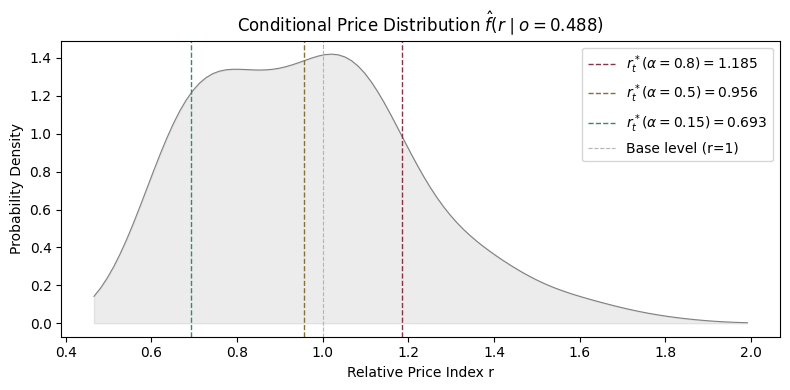

In [103]:
# Example: pricing for the first forecasted day
dat_index = 12 
target_date = forecasted_dates[dat_index] 
target_occupancy = float(forecasted_occupancy[dat_index]) 

prices_axis, conditional_pdf = extract_conditional_distribution( occupancy_grid, price_grid, density_grid, target_occupancy )

recommended_relative_price = select_price_quantile(prices_axis, conditional_pdf, PRICING_QUANTILE) 
recommended_relative_price_aggresive = select_price_quantile(prices_axis, conditional_pdf, AGGRESIVE_QUANTILE) 
recommended_relative_price_lean = select_price_quantile(prices_axis, conditional_pdf, LEAN_QUANTILE) 

print(f"Relative price recommendation r*_t (alpha={PRICING_QUANTILE}) : {recommended_relative_price:.4f}") 
print(f"Relative price recommendation r*_t (alpha={AGGRESIVE_QUANTILE}) : {recommended_relative_price_aggresive:.4f}") 
print(f"Relative price recommendation r*_t (alpha={LEAN_QUANTILE}) : {recommended_relative_price_lean:.4f}") 

plt.figure(figsize=(8, 4)) 
plt.fill_between(prices_axis, conditional_pdf, alpha=0.15, color='grey') 
plt.plot(prices_axis, conditional_pdf, color='grey', linewidth=0.8) 

plt.axvline( recommended_relative_price_aggresive, color="#883341", linewidth=1, linestyle='--', label=rf'$r^*_t(\alpha={AGGRESIVE_QUANTILE}) = {recommended_relative_price_aggresive:.3f}$' ) 
plt.axvline( recommended_relative_price, color="#88703c", linewidth=1, linestyle='--', label=rf'$r^*_t(\alpha={PRICING_QUANTILE}) = {recommended_relative_price:.3f}$' ) 
plt.axvline( recommended_relative_price_lean, color="#338876", linewidth=1, linestyle='--', label=rf'$r^*_t(\alpha={LEAN_QUANTILE}) = {recommended_relative_price_lean:.3f}$' ) 
plt.axvline(1.0, color="#B4B4B4", linestyle='--', linewidth=0.8, label='Base level (r=1)') 

plt.title(f'Conditional Price Distribution $\hat{{f}}(r \mid o={target_occupancy:.3f})$') 
plt.xlabel('Relative Price Index r') 
plt.ylabel('Probability Density') 

plt.legend() 
plt.tight_layout() 
plt.show()

In [98]:
# Apartment-specific price recommendations: p*_{a,t} = r*_t x p_bar_a
apartment_prices = recommend_apartment_prices(recommended_relative_price, base_prices)
print(f"Recommended prices per bed for {target_date.date()}:")
apartment_prices.reset_index()

Recommended prices per bed for 2025-05-09:


,apartment_id,recommended_price_per_bed
0,0,179748.798866
1,1,179945.371105
2,2,140098.159136
3,3,126269.837681
4,4,128476.625681
5,5,144243.383578
6,6,155210.259942
7,7,155550.962873
8,8,206085.081973
9,9,154759.734346


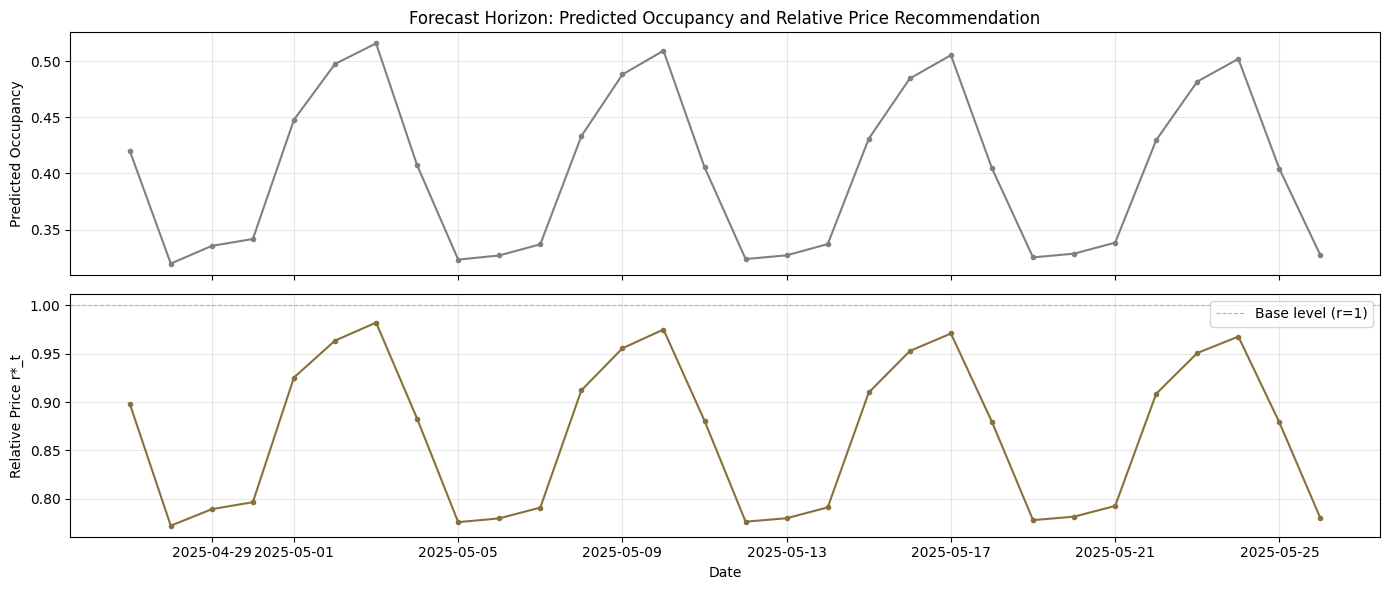

,predicted_occupancy,relative_price
date,,
2025-04-27,0.4204,0.8984
2025-04-28,0.3197,0.7719
2025-04-29,0.3355,0.7890
2025-04-30,0.3416,0.7962
2025-05-01,0.4478,0.9253
2025-05-02,0.4975,0.9636
2025-05-03,0.5159,0.9823
2025-05-04,0.4073,0.8828
2025-05-05,0.3233,0.7755


In [102]:
# Recommendations across the full forecast horizon
records = []

for date, predicted_occ in zip(forecasted_dates, forecasted_occupancy):
    try:
        p_axis, cond_pdf = extract_conditional_distribution(
            occupancy_grid, price_grid, density_grid, predicted_occ
        )
        rel_price  = select_price_quantile(p_axis, cond_pdf, PRICING_QUANTILE)
        apt_prices = recommend_apartment_prices(rel_price, base_prices)
        records.append({
            'date': date,
            'predicted_occupancy': predicted_occ,
            'relative_price': rel_price,
            **{f'apt_{aid}_price': price for aid, price in apt_prices.items()},
        })
    except ValueError as e:
        print(f"Skipping {date.date()}: {e}")

recommendations = pd.DataFrame(records).set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(recommendations.index, recommendations['predicted_occupancy'], marker='o', markersize=3, color='gray')
axes[0].set_ylabel('Predicted Occupancy')
axes[0].set_title('Forecast Horizon: Predicted Occupancy and Relative Price Recommendation')
axes[0].grid(True, alpha=0.3)

axes[1].plot(recommendations.index, recommendations['relative_price'], marker='o', markersize=3, color='#88703c')
axes[1].axhline(1.0, color='#B4B4B4', linestyle='--', linewidth=0.8, label='Base level (r=1)')
axes[1].set_ylabel('Relative Price r*_t')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

recommendations[['predicted_occupancy', 'relative_price']].round(4)

In [158]:
# Table of recommendations for the first N forecasted days, including actual occupancy and price comparison
NUMBER_OF_DATES = 30
APPARTMNENT_INDEX = 7
TABLE_QUANTILE = 0.5

base_price = base_prices.loc[APPARTMNENT_INDEX]

rel_prices, rec_prices = [], []
for occ in forecasted_occupancy[:NUMBER_OF_DATES]:
    p_axis, cond_pdf = extract_conditional_distribution(
        occupancy_grid, price_grid, density_grid, occ
    )
    rel = select_price_quantile(p_axis, cond_pdf, TABLE_QUANTILE)
    rel_prices.append(rel)
    rec_prices.append(rel * base_price)

actual_prices = (
    daily_stays[daily_stays['apartment_id'] == APPARTMNENT_INDEX]
    .set_index('stay_date')['nightly_bed_rate']
    .rename('Observed Price')
)

apt_results = (
    recommendations.head(NUMBER_OF_DATES)[['predicted_occupancy']]
    .rename(columns={'predicted_occupancy': 'Predicted Occ.'})
    .join(test_occupancy.rename('Observed Occ.'))
    .assign(**{
        'Occ. Diff.': lambda df: (df['Observed Occ.'] - df['Predicted Occ.']) * 100,
        f'Rel. Price r* (α={TABLE_QUANTILE})': rel_prices,
        'Recom. Price': rec_prices,
    })
    .join(actual_prices)
    .assign(**{
        'Price Diff.': lambda df: (
            (df['Recom. Price'] / df['Observed Price'] - 1) * 100
        ).round(1),
    })
)

corr = apt_results['Occ. Diff.'].corr(apt_results['Price Diff.'])
print(f"Correlation (Occ. Diff. vs. Price Diff.): {corr:.4f}")

czk = lambda x: f'{x / 100:,.2f}'.replace(',', '\N{NARROW NO-BREAK SPACE}')

apt_results.style.format({
    'Predicted Occ.':                       '{:.1%}',
    'Observed Occ.':                        '{:.1%}',
    'Occ. Diff.':                           '{:+.1f}',
    f'Rel. Price r* (α={TABLE_QUANTILE})':  '{:.4f}',
    'Recom. Price':                         czk,
    'Observed Price':                       czk,
    'Price Diff.':                          '{:+.1f}%',
}, na_rep='—').set_caption(
    f'Apartment {APPARTMNENT_INDEX} — first {NUMBER_OF_DATES} forecast days (α={TABLE_QUANTILE})'
)

Correlation (Occ. Diff. vs. Price Diff.): -0.1881


,Predicted Occ.,Observed Occ.,Occ. Diff.,Rel. Price r* (α=0.5),Recom. Price,Observed Price,Price Diff.
date,,,,,,,
2025-04-27 00:00:00,42.0%,40.4%,-1.7,0.8984,1 462.38,—,—
2025-04-28 00:00:00,32.0%,22.8%,-9.2,0.7719,1 256.34,—,—
2025-04-29 00:00:00,33.6%,5.3%,-28.3,0.7890,1 284.26,—,—
2025-04-30 00:00:00,34.2%,26.3%,-7.8,0.7962,1 296.05,3 288.77,-60.6%
2025-05-01 00:00:00,44.8%,64.9%,+20.1,0.9253,1 506.17,3 288.77,-54.2%
2025-05-02 00:00:00,49.8%,61.4%,+11.7,0.9636,1 568.41,3 288.77,-52.3%
2025-05-03 00:00:00,51.6%,59.6%,+8.1,0.9823,1 598.86,3 288.77,-51.4%
2025-05-04 00:00:00,40.7%,29.8%,-10.9,0.8828,1 436.86,2 280.08,-37.0%
2025-05-05 00:00:00,32.3%,40.4%,+8.0,0.7755,1 262.31,2 280.08,-44.6%
